# Do zero — devagar, um passo por vez

**Pedro, este notebook começa do NADA.** Sem pressa. Uma ideia por célula.
Se alguma célula não fizer sentido, para ali e me pergunta — não pula.

Regra do jogo: aperte `Shift+Enter` em cada célula, na ordem. Só isso.

---

## Passo 0 — a pergunta que estamos tentando responder

Imagina dois átomos flutuando num tanque geladíssimo, quase parados.
Eles se aproximam um do outro. Existe uma "cola" fraca entre eles
(atração). A pergunta do nosso projeto inteiro é uma só:

> **Quando dois átomos se encontram, eles grudam ou só se esbarram e seguem em frente?**

Tudo que a gente construiu serve pra responder essa pergunta. Sério, é só isso.

In [1]:
# Esta célula só liga as ferramentas de desenhar gráficos. Rode e esqueça.
%matplotlib inline
import numpy as np                  # numpy = calculadora de listas de números
import matplotlib.pyplot as plt    # matplotlib = quem desenha os gráficos
print("Ferramentas ligadas. Bora.")

Ferramentas ligadas. Bora.


---
## Passo 1 — o "mapa da atração" (que os físicos chamam de potencial)

Antes de qualquer conta, precisamos descrever a cola entre os átomos.
Fazemos isso com um gráfico bem simples:

- **eixo horizontal**: a distância entre os DOIS átomos (perto ← → longe)
- **eixo vertical**: energia. **Zero = não sentem nada. Negativo = atração.**

Pensa num vale: se o gráfico desce, é porque ali os átomos "querem" ficar.

Vamos desenhar o nosso vale:

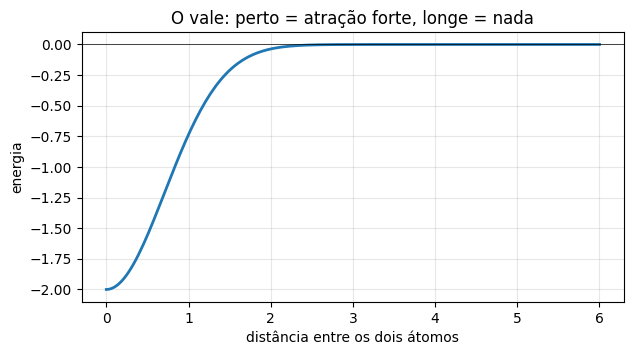

In [2]:
distancia = np.linspace(0, 6, 200)          # 200 pontos de distância, de 0 a 6
vale = -2.0 * np.exp(-distancia**2)          # a fórmula do vale (decorar? NÃO. só olhar o desenho)

plt.figure(figsize=(7, 3.5))
plt.plot(distancia, vale, lw=2)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distância entre os dois átomos")
plt.ylabel("energia")
plt.title("O vale: perto = atração forte, longe = nada")
plt.grid(alpha=0.3)
plt.show()

**Olha o desenho e me diz (mentalmente):**

- Perto de distância 0, o gráfico está lá embaixo → atração forte.
- Perto de distância 3, o gráfico já é praticamente zero → os átomos nem se sentem.

Pronto. Você acabou de ler um "potencial". É SÓ ISSO que essa palavra
assustadora significa: o desenho do vale.

---
## Passo 2 — a partícula quântica é uma onda

No mundo quântico, a gente não desenha a bolinha do átomo; a gente
desenha uma **onda** que diz por onde o par de átomos "se espalha".
Vamos chamar essa onda de `u`. É só um gráfico também.

A equação de Schrödinger (o nome famoso) diz uma coisa simples sobre
essa onda:

> **"Dentro do vale, a onda entorta. Fora do vale, ela segue reta."**

Guarda essa frase. Ela é 80% do projeto.

---
## Passo 3 — vamos CONSTRUIR a onda na mão, tipo dominó

Como o computador desenha a onda? Peça por peça, feito dominó:

1. A onda começa valendo **0** bem no centro.
2. Damos um empurrãozinho: o ponto seguinte vale **1** (o valor exato não importa).
3. A partir daí, uma receita diz o valor do PRÓXIMO ponto usando os dois anteriores:

**próximo = 2×(atual) − (anterior) + (empurrão do vale)×(atual)**

O "empurrão do vale" é grande dentro do vale e zero fora. Vamos fazer
só 8 passos e IMPRIMIR cada um, pra você ver que é aritmética de padaria:

In [3]:
passo = 0.5                                  # tamanho de cada passo de distância
u_anterior = 0.0                             # regra 1: começa em zero
u_atual = 1.0                                # regra 2: empurrãozinho

print("distância | valor da onda u")
print(f"   0.0    |  {u_anterior}")
print(f"   0.5    |  {u_atual}")

for i in range(2, 10):
    r = i * passo                            # em que distância estamos
    profundidade_aqui = -2.0 * np.exp(-r**2) # quanto vale o vale AQUI
    empurrao = 2 * passo**2 * profundidade_aqui
    u_proximo = 2*u_atual - u_anterior + empurrao * u_atual   # A RECEITA
    print(f"   {r:.1f}    |  {u_proximo:.3f}")
    u_anterior, u_atual = u_atual, u_proximo # anda uma casa no dominó

distância | valor da onda u
   0.0    |  0.0
   0.5    |  1.0
   1.0    |  1.632
   1.5    |  2.092
   2.0    |  2.514
   2.5    |  2.931
   3.0    |  3.347
   3.5    |  3.764
   4.0    |  4.181
   4.5    |  4.597


**Olha a tabela que você acabou de gerar.** Cada linha nasceu das duas
anteriores com UMA continha. É isso que o "solver" faz — só que com
20 mil passos minúsculos em vez de 8 passos grandões. Não tem mágica,
tem repetição.

---
## Passo 4 — agora com passos pequenos, pra onda ficar lisa

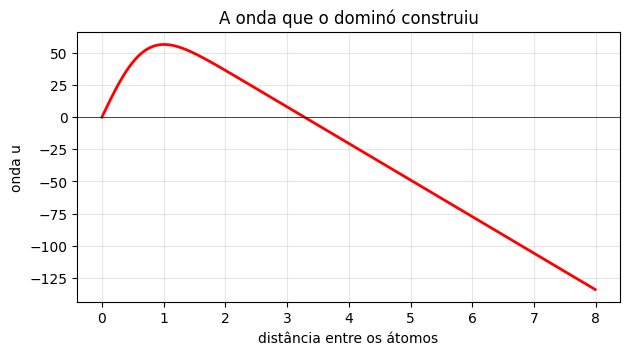

In [4]:
def constroi_onda(profundidade_do_vale):
    passo = 0.01                             # passos bem pequenos agora
    n = 800                                  # 800 pontos -> vai até distância 8
    r = np.arange(n) * passo
    vale = -profundidade_do_vale * np.exp(-r**2)
    u = np.zeros(n)
    u[1] = 1.0                               # o empurrãozinho
    for i in range(1, n-1):                  # o dominó, 800 vezes
        u[i+1] = 2*u[i] - u[i-1] + 2*passo**2 * vale[i] * u[i]
    return r, u

r, u = constroi_onda(profundidade_do_vale=2.0)

plt.figure(figsize=(7, 3.5))
plt.plot(r, u, 'r-', lw=2)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distância entre os átomos"); plt.ylabel("onda u")
plt.title("A onda que o dominó construiu")
plt.grid(alpha=0.3); plt.show()

**O que olhar:** perto do começo (dentro do vale) a curva ENTORTA.
Depois da distância ~2 (onde o vale acabou), ela vira uma **RETA**.
Exatamente a frase do Passo 2.

---
## Passo 5 — o número mágico: onde a reta aponta

Agora o pulo do gato do projeto inteiro. Aquela reta do final: estica
ela com uma régua. **Ela cruza o chão (o zero) em algum lugar.**

Esse ponto de cruzamento tem nome: **comprimento de espalhamento**,
apelido **a**. E ele responde a pergunta do Passo 0:

- Se a reta cruza o chão "na frente" (**a positivo**) → **os átomos GRUDAM** (formam molécula)
- Se cruza "atrás", do lado negativo (**a negativo**) → **quase grudam, mas não grudam**
- Se a reta fica deitada, sem nunca cruzar (**a infinito**) → o caso especial no fio da navalha (o queridinho do seu mestrado)

Vamos achar o cruzamento com geometria de ensino médio (inclinação da reta):

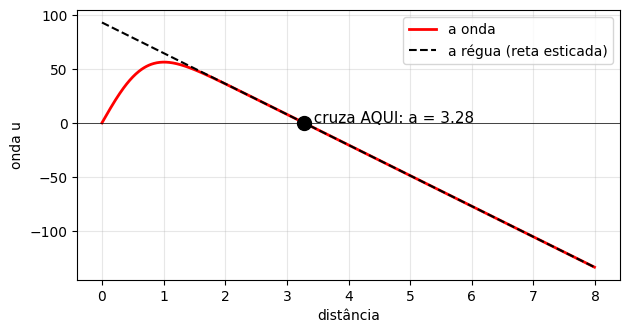

a = 3.279  ->  positivo = os átomos formam molécula!


In [5]:
# pega dois pontos do FINAL da onda (onde já é reta) e estica a régua
x1, y1 = r[-100], u[-100]
x2, y2 = r[-1],   u[-1]
inclinacao = (y2 - y1) / (x2 - x1)
a = x1 - y1 / inclinacao                     # onde a reta cruza o zero

plt.figure(figsize=(7, 3.5))
plt.plot(r, u, 'r-', lw=2, label='a onda')
reta_x = np.linspace(0, 8, 50)
reta_y = y1 + inclinacao * (reta_x - x1)
plt.plot(reta_x, reta_y, 'k--', label='a régua (reta esticada)')
plt.plot([a], [0], 'ko', ms=10)
plt.annotate(f'  cruza AQUI: a = {a:.2f}', (a, 0), fontsize=11)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distância"); plt.ylabel("onda u")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print(f"a = {a:.3f}  ->  positivo = os átomos formam molécula!")

---
## Passo 6 — brinca você agora: gira a profundidade do vale

Roda a célula abaixo. Depois **troca o número da profundidade**
(tenta 0.5, depois 1.34, depois 3.0) e roda de novo. Observa o que a
reta faz e o que acontece com o `a`:

- **0.5** (vale raso): reta cruza atrás → a negativo → não gruda
- **1.34** (vale no ponto crítico): reta quase deitada → a gigante → fio da navalha
- **3.0** (vale fundo): cruza na frente, perto → a positivo pequeno → gruda firme

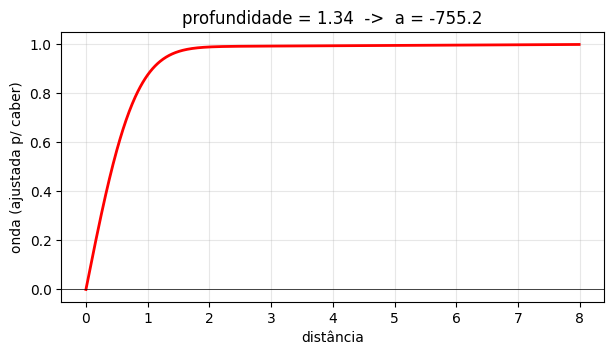

a = -755 -> GIGANTE: fio da navalha (unitariedade)


In [6]:
profundidade = 1.34                          # <<< TROCA ESTE NÚMERO E RODA DE NOVO

r, u = constroi_onda(profundidade)
x1, y1, x2, y2 = r[-100], u[-100], r[-1], u[-1]
incl = (y2-y1)/(x2-x1)
a = x1 - y1/incl

plt.figure(figsize=(7, 3.5))
plt.plot(r, u/abs(u[-1]), 'r-', lw=2)        # (dividido só pra caber no gráfico)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distância"); plt.ylabel("onda (ajustada p/ caber)")
plt.title(f"profundidade = {profundidade}  ->  a = {a:.1f}")
plt.grid(alpha=0.3); plt.show()
if a > 50 or a < -50:
    print(f"a = {a:.0f} -> GIGANTE: fio da navalha (unitariedade)")
elif a > 0:
    print(f"a = {a:.2f} -> positivo: gruda (forma molécula)")
else:
    print(f"a = {a:.2f} -> negativo: quase gruda, mas não")

---
## Recapitulando — o projeto inteiro em 5 frases

1. Dois átomos se atraem: desenhamos o **vale** da atração.
2. A onda deles **entorta dentro do vale e fica reta fora**.
3. O computador constrói a onda como **dominó** (cada ponto vem dos dois anteriores).
4. Esticamos a **régua** na parte reta: onde cruza o chão é o número **a**.
5. O sinal de **a** responde tudo: positivo = gruda, negativo = não gruda,
   gigante = fio da navalha — e é NESSE fio da navalha que vive o efeito
   Efimov, o tema do seu mestrado.

**Todo o resto do projeto** (os 4 potenciais, o r₀, o ajuste, o ³⁹K, a
torre de Efimov...) são variações e refinamentos dessas 5 frases.

### Próximo passo (quando este aqui estiver confortável)
Notebook `01_visita_guiada` — mesma história, com os potenciais de
verdade do artigo. Sem pressa. E qualquer célula que travar: me chama.